# Outline

This notebook is used to conduct data analysis step by step before entering preprocessing and prediction. This will help me decide what I need to do to preprocess the data.

Notebook Outline

1. Load Data And Library
2. Check Data Basic Information
3. Data Visualization
4. Correlation Map

# Load Data And Library

In [1]:
# import necessary library
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder,LabelEncoder
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [2]:
# config
class CFG:
    train_csv = '/kaggle/input/competitions/playground-series-s6e3/train.csv'
    test_csv = '/kaggle/input/competitions/playground-series-s6e3/test.csv'
    sample_submission_csv = '/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv'
    N_FOLDS = 5
    RANDOM_SEED = 42
    
#torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
train = pd.read_csv(CFG.train_csv)
test = pd.read_csv(CFG.test_csv)

# Check Data Basic Information

In [4]:
#check what is in the data
print("------------train data------------")
display(train.head())
print(train.describe())
print("------------test data------------")
display(test.head())
print(test.describe())

------------train data------------


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


                  id  SeniorCitizen         tenure  MonthlyCharges  \
count  594194.000000  594194.000000  594194.000000   594194.000000   
mean   297096.500000       0.114102      36.577258       65.866223   
std    171529.177262       0.317936      25.061922       31.067444   
min         0.000000       0.000000       1.000000       18.250000   
25%    148548.250000       0.000000      12.000000       29.900000   
50%    297096.500000       0.000000      35.000000       74.100000   
75%    445644.750000       0.000000      62.000000       90.800000   
max    594193.000000       1.000000      72.000000      118.750000   

        TotalCharges  
count  594194.000000  
mean     2494.377057  
std      2353.916710  
min        18.800000  
25%       639.650000  
50%      1433.650000  
75%      4263.800000  
max      8684.800000  
------------test data------------


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


                  id  SeniorCitizen         tenure  MonthlyCharges  \
count  254655.000000   254655.00000  254655.000000   254655.000000   
mean   721521.000000        0.11362      37.279716       66.130803   
std     73512.710738        0.31735      24.777625       31.104139   
min    594194.000000        0.00000       1.000000       18.300000   
25%    657857.500000        0.00000      13.000000       30.150000   
50%    721521.000000        0.00000      36.000000       74.350000   
75%    785184.500000        0.00000      62.000000       91.100000   
max    848848.000000        1.00000      72.000000      118.750000   

        TotalCharges  
count  254655.000000  
mean     2544.617351  
std      2348.124379  
min        18.800000  
25%       677.625000  
50%      1468.750000  
75%      4317.300000  
max      8684.800000  


In [5]:
# check if there is miss data in training data or testing data
print(train.isnull().sum())
print(test.isnull().sum())

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


# Data Visualization

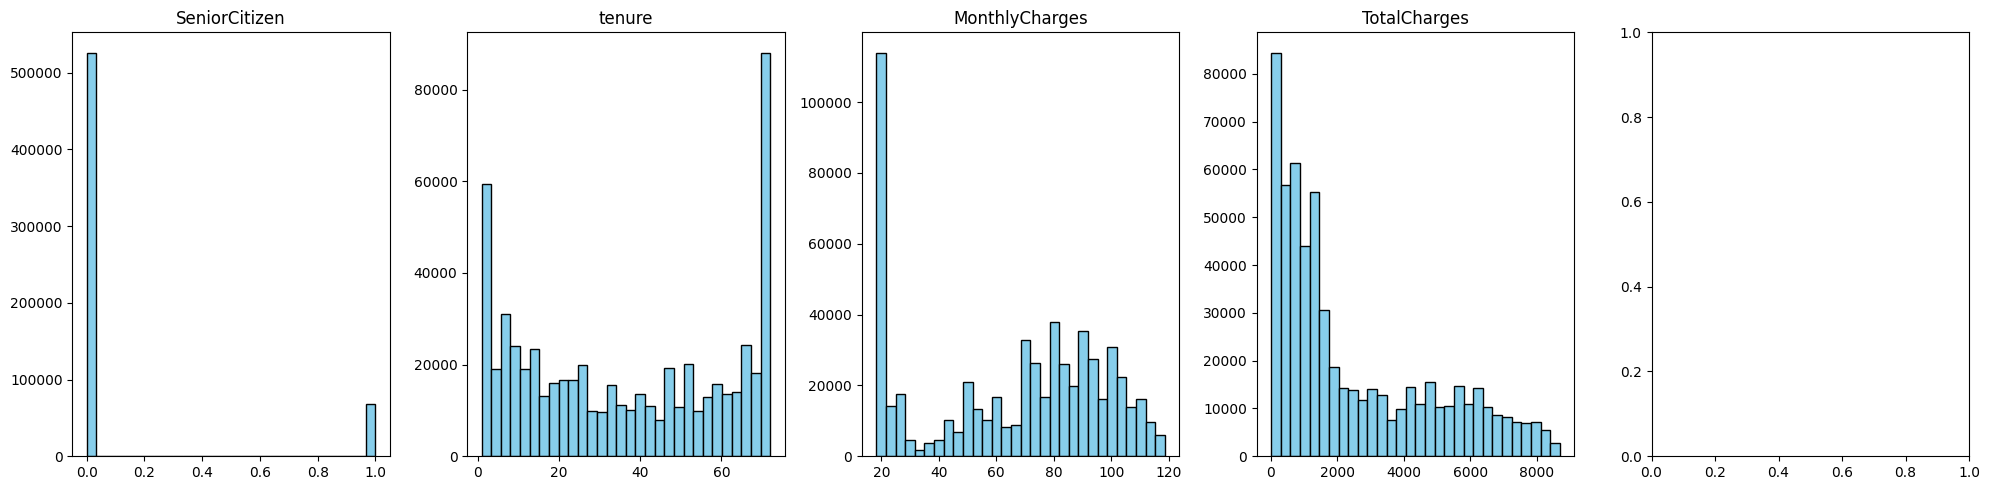

In [6]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id']]
total_col = len(numeric_cols)
subplot_x = int(total_col / 5) + 1
subplot_y = 5

fig, axs = plt.subplots(subplot_x, subplot_y, figsize=(20, 5)) # Adjust grid size as needed
axs = axs.flatten() # Flattens the 2D grid to 1D

for i, col in enumerate(numeric_cols):
    if i < len(axs):
        axs[i].hist(train[col], bins=30, color='skyblue', edgecolor='black')
        axs[i].set_title(col)
    else:
        axs[i].axis('off') # Hide unused subplots

plt.tight_layout()
plt.show()

**KEY NOTE: Check every non numeric feature for every possible categories in it. In real circumstances might need to consider there will be a data that is not in the train dataset so in preprocess need to avoid this from happening,**

In [7]:
non_numeric_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()
for col in non_numeric_cols:
    print(col," : ",train[col].unique())

gender  :  ['Male' 'Female']
Partner  :  ['Yes' 'No']
Dependents  :  ['Yes' 'No']
PhoneService  :  ['Yes' 'No']
MultipleLines  :  ['No' 'Yes' 'No phone service']
InternetService  :  ['DSL' 'Fiber optic' 'No']
OnlineSecurity  :  ['Yes' 'No' 'No internet service']
OnlineBackup  :  ['No' 'Yes' 'No internet service']
DeviceProtection  :  ['Yes' 'No' 'No internet service']
TechSupport  :  ['Yes' 'No' 'No internet service']
StreamingTV  :  ['No' 'Yes' 'No internet service']
StreamingMovies  :  ['No' 'Yes' 'No internet service']
Contract  :  ['One year' 'Two year' 'Month-to-month']
PaperlessBilling  :  ['Yes' 'No']
PaymentMethod  :  ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']
Churn  :  ['No' 'Yes']


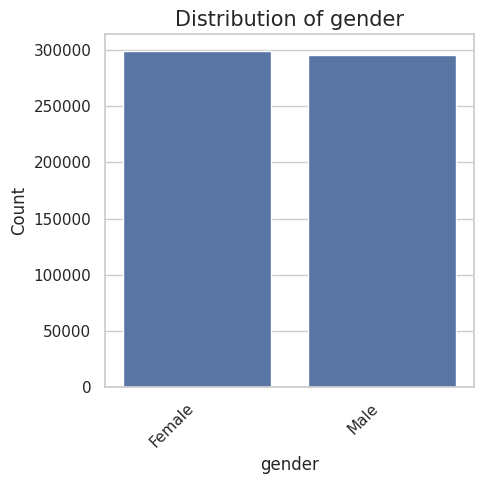

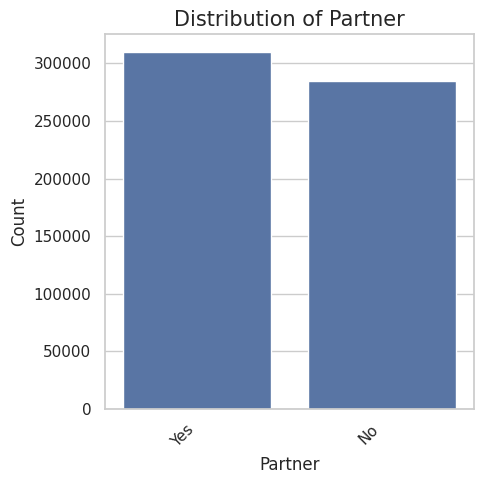

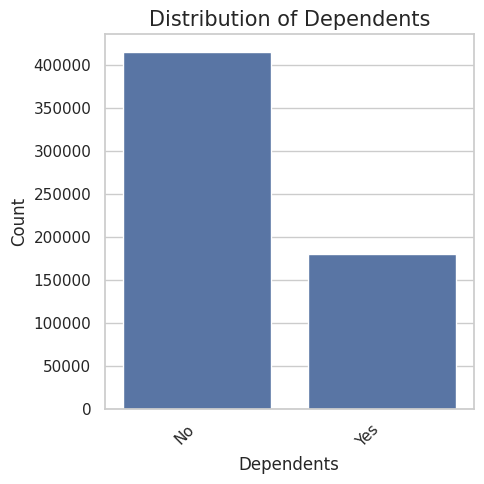

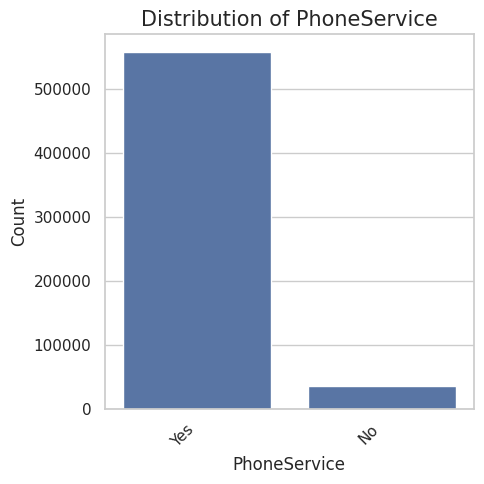

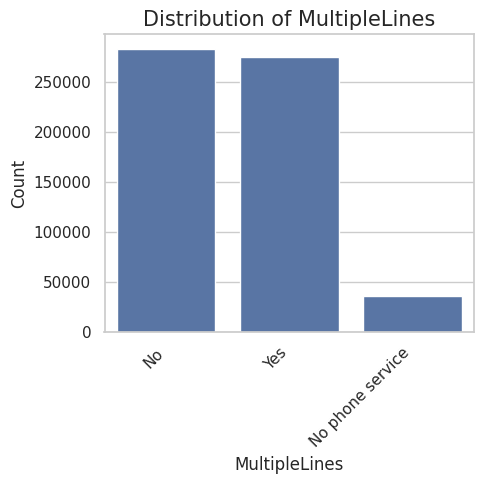

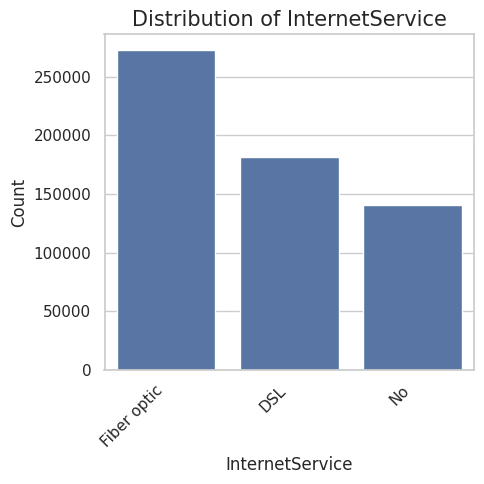

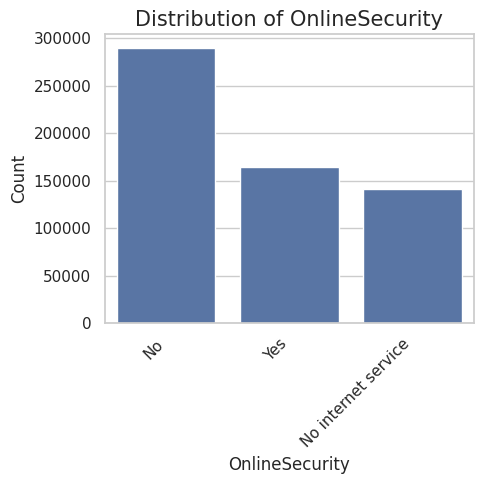

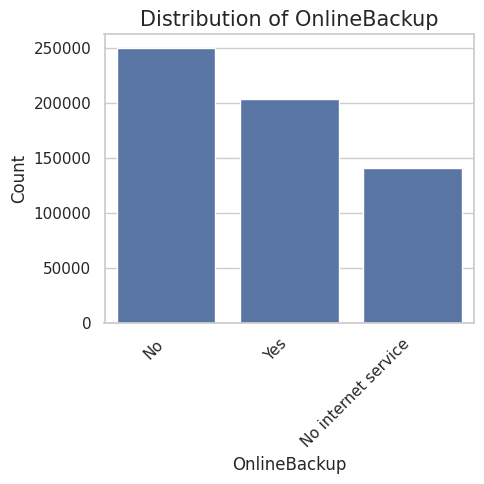

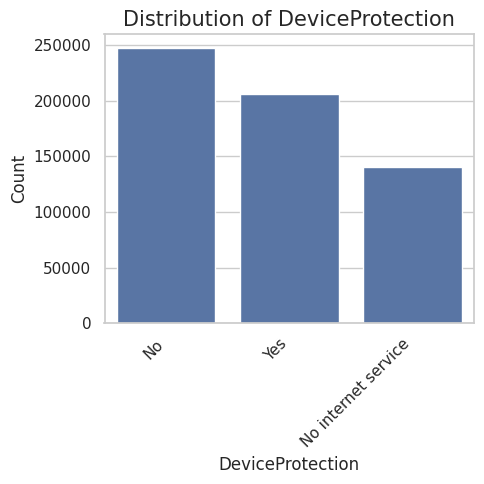

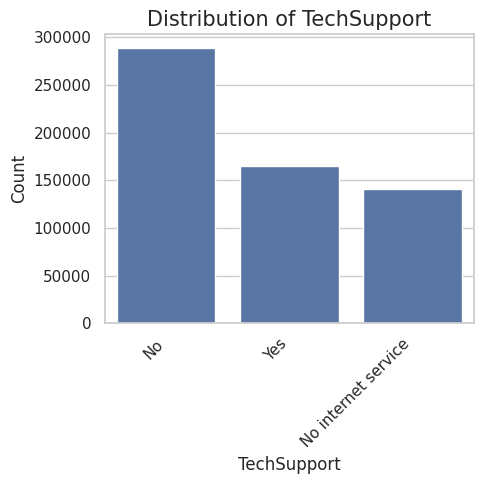

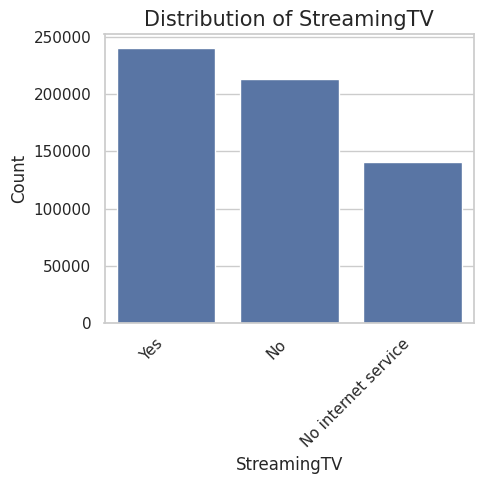

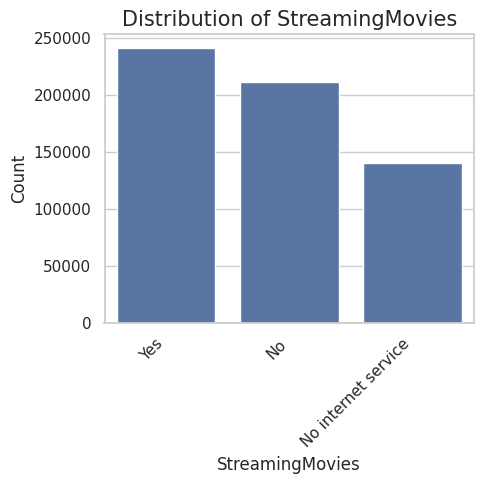

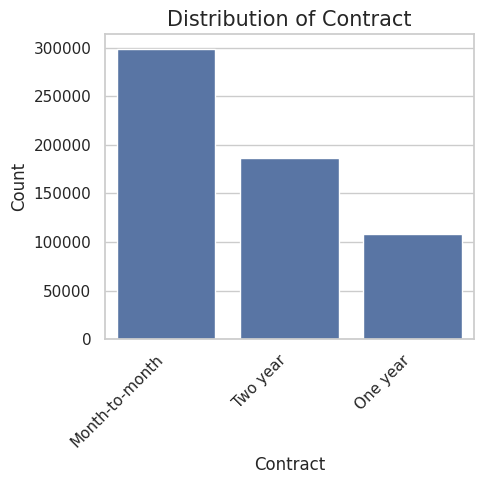

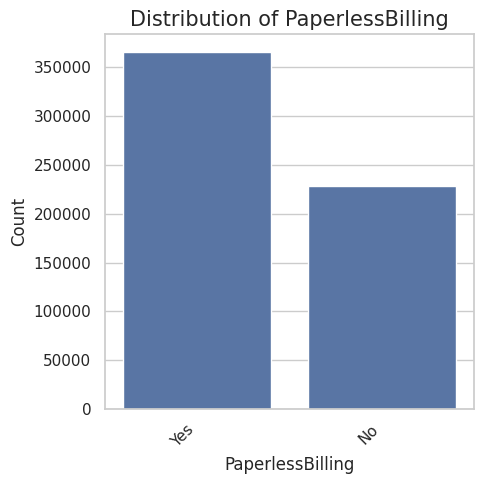

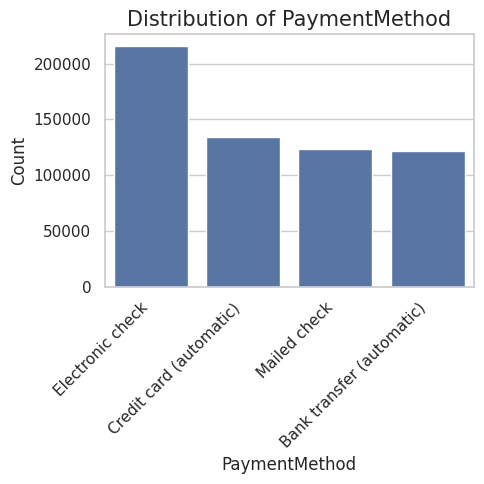

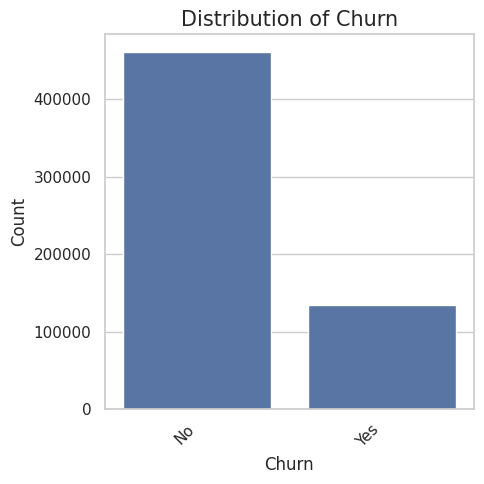

In [8]:
sns.set(style="whitegrid")
#PLOT NON NUMERIC DATA
for col in non_numeric_cols:
    # (width, height)
    plt.figure(figsize=(5, 5))
    
    # order plot with most number to least number data
    sns.countplot(data=train, x=col, order=train[col].value_counts().index)
    
    # title and x label
    plt.title(f'Distribution of {col}', fontsize=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # rotate to avoid x axis on top of each other
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

In [9]:
train_raw = train.drop(columns=['id'])
train_raw.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [10]:
one_hot_encoded_train_raw = pd.get_dummies(train_raw)

# Correlation Map

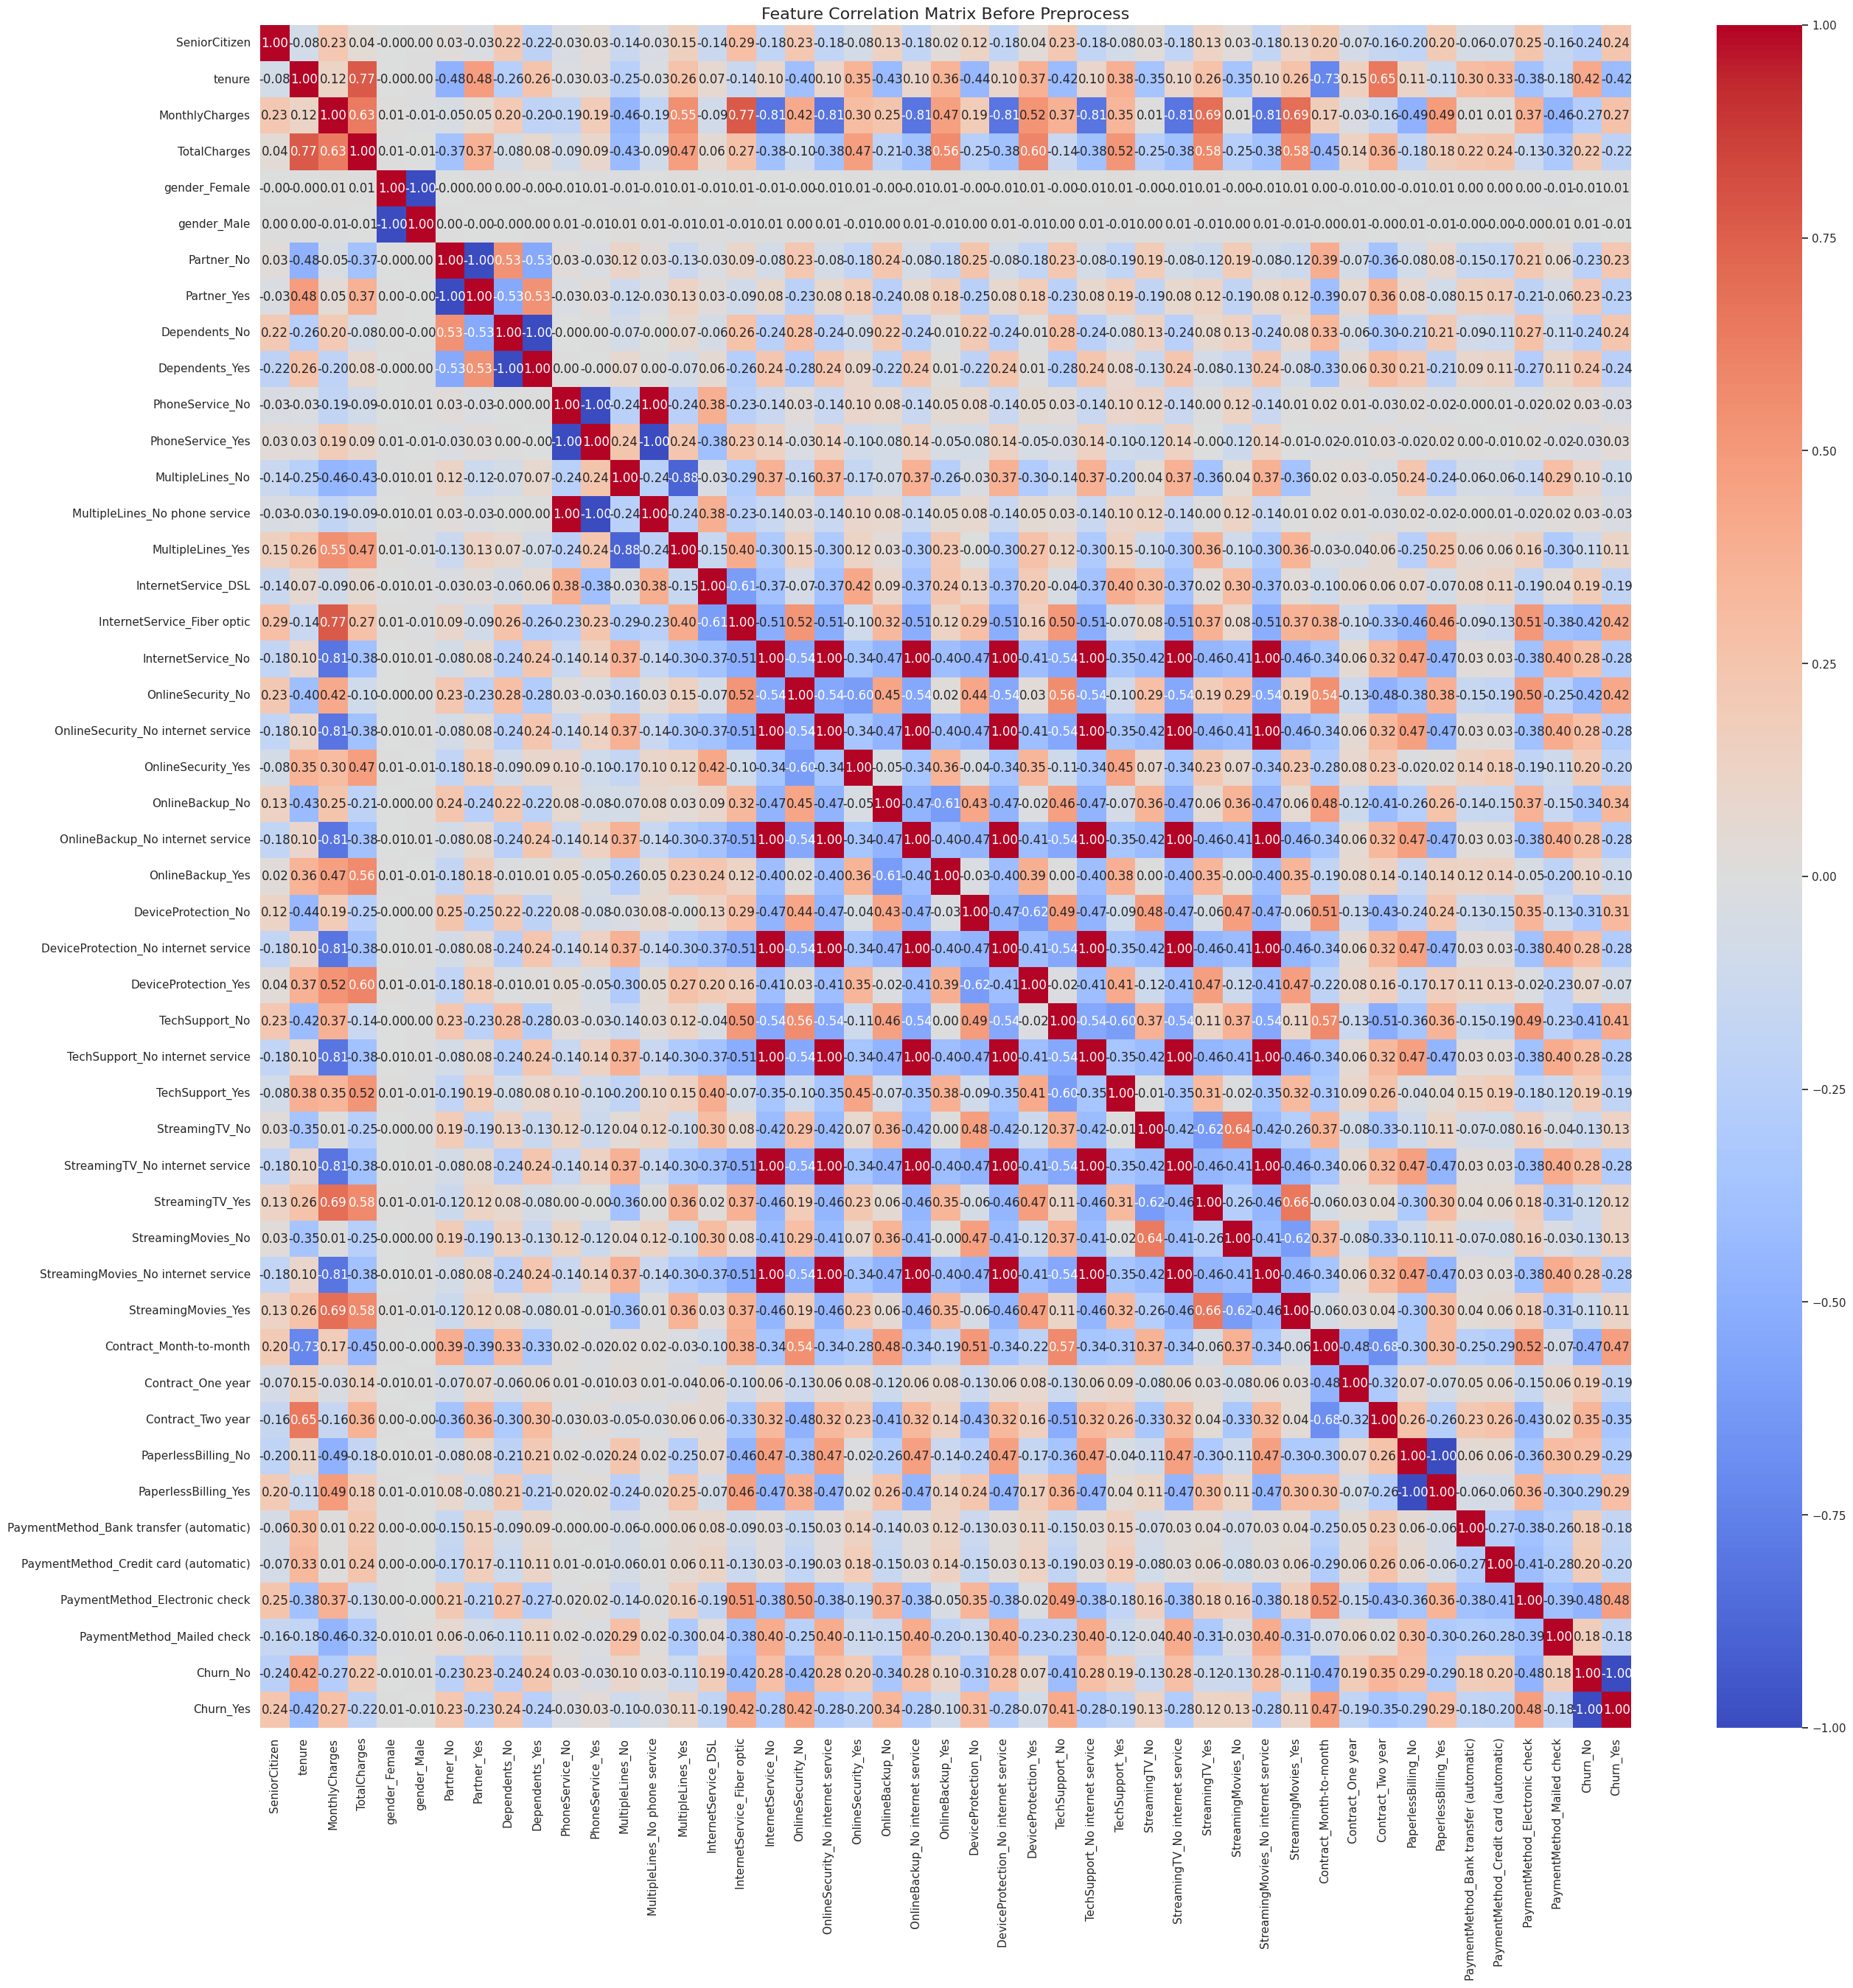

In [11]:
# Check the correlation map before preprocess
# Then compare it with the correlation map of after preprocess 
corr_matrix = one_hot_encoded_train_raw.corr()

# Setup the figure size (make it large enough to read)
plt.figure(figsize=(30, 30))

# Create the Heatmap
# annot=True: shows the numbers
# cmap='coolwarm': Blue for negative corr, Red for positive
# fmt=".2f": limits decimals to 2 places
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Feature Correlation Matrix Before Preprocess", fontsize=16)
plt.show()

# Conclusion

1. TotalCharges vs. tenure & MonthlyCharges: TotalCharges shows a very strong positive correlation with both ($0.77) and $0.63 respectively. This is reasonable because the total cost is typically the monthly fee multiplied by the lease term.

2. Dummy Variables : gender_Female and gender_Male are completely negatively correlated at -1.00. This is because we use one hot encoded for correlation matrix. Therefore we can ignore this problem.

3. TotalCharges can be removed because this is almost the same as tenure and MonthlyCharges.

4. SeniorCitizen doesn't seem to have a strong correlation with other services. Cross-features could be explored for a better feature.

5. Monthly Fee Ratio: A new feature, MonthlyCharges / TotalCharges, can be created to see if customers have churned due to recent rate increases.

# Preprocess

This preprocess will be ready to use for model.

In [12]:
train_copy = train.drop(columns=['id'])
train_copy.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [13]:
# Binary data
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    train_copy[col] = train_copy[col].apply(lambda x: 1 if x in ['Yes', 'Male'] else 0)

# Simplify「No internet service」as No
replace_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in replace_cols:
    train_copy[col] = train_copy[col].replace('No internet service', 'No')
    train_copy[col] = train_copy[col].replace('No phone service', 'No')
    # Transform data into binary
    train_copy[col] = train_copy[col].apply(lambda x: 1 if x == 'Yes' else 0)

# Ordinal data
contract_mapping = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
train_copy['Contract'] = train_copy['Contract'].map(contract_mapping)

# Rest feature OHE
train_copy = pd.get_dummies(train_copy, columns=['InternetService', 'PaymentMethod'], drop_first=True, dtype=int)

In [14]:
train_copy.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,1,29,1,0,1,0,1,...,1,1,60.10,1653.85,0,0,0,0,0,1
1,1,0,1,1,58,1,0,1,1,0,...,2,0,69.50,3778.20,0,0,0,1,0,0
2,1,0,1,0,58,1,1,0,1,0,...,0,1,100.40,5841.35,0,1,0,0,1,0
3,0,0,0,0,1,1,0,0,0,0,...,0,1,69.70,70.70,1,1,0,0,1,0
4,0,0,0,0,1,1,0,0,0,0,...,0,1,70.45,70.45,1,1,0,0,1,0


This preprocess class can be directly used in pipline.

In [15]:
class Preprocessor:
    def __init__(self):
        self.medians = {}
        self.scaler = StandardScaler()
        self.one_hot_encoder = None
        
        self.binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
        self.replace_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                             'TechSupport', 'StreamingTV', 'StreamingMovies']
        self.contract_mapping = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
        self.ohe_cols = ['InternetService', 'PaymentMethod']
        self.numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

    def create_interaction_features(self, df):
        df = df.copy()
        
        if 'TotalCharges' in df.columns:
            df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
        
        if 'MonthlyCharges' in df.columns and 'TotalCharges' in df.columns:
            df['Monthly_Fee_Ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)
        return df

    def fit(self, df, y=None):
        df_tmp = self.create_interaction_features(df)
        
        # learn median value
        curr_num_cols = df_tmp.select_dtypes(include=[np.number]).columns.tolist()
        for col in curr_num_cols:
            self.medians[col] = df_tmp[col].median()
            
        # fit OneHotEncoder
        self.one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
        self.one_hot_encoder.fit(df_tmp[self.ohe_cols].astype(str))
        
        return self

    def transform(self, df):
        df = df.copy()
        df = self.create_interaction_features(df)
        
        if 'id' in df.columns: df = df.drop(columns=['id'])
        
        # Binary Encoding
        for col in self.binary_cols:
            if col in df.columns:
                df[col] = df[col].apply(lambda x: 1 if x in ['Yes', 'Male'] else 0)

        # No internet service and No phone service to No
        for col in self.replace_cols:
            if col in df.columns:
                df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})
                df[col] = df[col].apply(lambda x: 1 if x == 'Yes' else 0)

        # Ordinal Encoding
        if 'Contract' in df.columns:
            df['Contract'] = df['Contract'].map(self.contract_mapping).fillna(0).astype(int)

        # fill median into miss value
        for col, val in self.medians.items():
            if col in df.columns:
                df[col] = df[col].fillna(val)

        # One-Hot Encoding (InternetService, PaymentMethod)
        encoded_array = self.one_hot_encoder.transform(df[self.ohe_cols].astype(str))
        encoded_cols = self.one_hot_encoder.get_feature_names_out(self.ohe_cols)
        encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index, dtype=int)
        
        df = pd.concat([df, encoded_df], axis=1)
        df = df.drop(columns=self.ohe_cols)
        
        if 'Churn' in df.columns and isinstance(df['Churn'].iloc[0], str):
            df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

        return df

In [16]:
preprocessor = Preprocessor()

X_train_raw = train.drop(columns=['id'])
y_train = train['Churn']

# learn the rule (median value...)
preprocessor.fit(X_train_raw)

# preprocess data
X_train_processed = preprocessor.transform(X_train_raw)

In [17]:
X_train_processed.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Monthly_Fee_Ratio,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,1,29,1,0,1,0,1,...,1,60.10,1653.85,0,0.036339,0,0,0,0,1
1,1,0,1,1,58,1,0,1,1,0,...,0,69.50,3778.20,0,0.018395,0,0,1,0,0
2,1,0,1,0,58,1,1,0,1,0,...,1,100.40,5841.35,0,0.017188,1,0,0,1,0
3,0,0,0,0,1,1,0,0,0,0,...,1,69.70,70.70,1,0.985856,1,0,0,1,0
4,0,0,0,0,1,1,0,0,0,0,...,1,70.45,70.45,1,1.000000,1,0,0,1,0


In [18]:
X_train_interact_feature = preprocessor.create_interaction_features(X_train_processed)
X_train_interact_feature.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Monthly_Fee_Ratio,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,1,29,1,0,1,0,1,...,1,60.10,1653.85,0,0.036339,0,0,0,0,1
1,1,0,1,1,58,1,0,1,1,0,...,0,69.50,3778.20,0,0.018395,0,0,1,0,0
2,1,0,1,0,58,1,1,0,1,0,...,1,100.40,5841.35,0,0.017188,1,0,0,1,0
3,0,0,0,0,1,1,0,0,0,0,...,1,69.70,70.70,1,0.985856,1,0,0,1,0
4,0,0,0,0,1,1,0,0,0,0,...,1,70.45,70.45,1,1.000000,1,0,0,1,0
